# Implementation of Experiments

# Dependencies


- [Couenne](https://www.coin-or.org/Couenne/): an open source branch&bound (B&B) algorithm for solving Mixed-Integer Nonlinear Programming (MINLP) problems

    ```shell
    # Make the directory if necessary
    #mkdir -p $HOME/.local/Couenne

    # Download the latest, e.g., https://www.coin-or.org/download/source/Couenne/Couenne-0.5.8.zip

    # Go the directory of the unpacked package, e.g., cd /path-to-project/Couenne-0.5.8
    # Checkout available options in configure
    ./configure --help

    # Install dependencies ASL, Blas, Lapack, and one of the HSL or MUMPS
    # ... if need latest packages, modify get.XXX for each ThirdParty package
    # ... note that HSL requires ordering the license (free for academic usage) before downloading
    # ... regarding which version of HSL (prebuilt or source), check out this email thread: https://list.coin-or.org/pipermail/couenne/2015-April/000432.html
    # ... or, alternatively, one can use MUMPS without HSL
    cd Couenne
    cd ThirdParty  # Read INSTALL.* file in each subdirectory and get third party software
    # If use MUMPS, for ThirdParty/Mumps/Makefile.in
    # ... change the line FFLAGS = @FFLAGS@ $(MY_FDEFS)
    # ... to FFLAGS = -fallow-argument-mismatch @FFLAGS@ $(MY_FDEFS)
    cd ..
    mkdir build.asl-20180528.blas-20130815.lapack-3.4.2.mumps-4.10.0
    cd build.asl-20180528.blas-20130815.lapack-3.4.2.mumps-4.10.0
    
    # If using Mumps
    ../configure -C
    
    make
    make install
    
    # Add dynamic lib path to DYLD_LIBRARY_PATH
    export DYLD_LIBRARY_PATH=$DYLD_LIBRARY_PATH:path-to-couenne-lib
    ```
    
- [Pyomo](http://www.pyomo.org/): an open source Python-based optimization modeling language

- Put a file `couenne.opt` in the same directory as this notebook to control Couenne solver's behavior ([User Manual](https://www.coin-or.org/Couenne/couenne-user-manual.pdf))


In [1]:
from pyomo.environ import (
    ConcreteModel,
    Var,
    Objective,
    Constraint,
    SolverFactory,
    # Integers,
    PositiveReals,
    minimize,
    exp,
    value,
)
import numpy as np
import pandas as pd
from math import factorial
from pprint import pprint
from copy import deepcopy

SOLVE_TEE = False  # output detailed optimization log

# Data Sources

## UC Data

link to UC data source

- GPA_HIGH 5.00
- GPA_LOW 0.00
- after negative log ratio scale, $-\log \big(\frac{S - LOW}{HIGH - LOW}\big)$, the score for a specific region is Gamma distributed

In [2]:
with open("data/UC_freshmen_systemwide.GPA_quantile.csv", "r") as f:
    df_GPA_statistic = pd.read_csv(f, delimiter=",")

GPA_HIGH = 5.0
GPA_LOW = 0.0
reference_quantiles_raw = np.array([4.0, 3.7, 3.3, 3.0])
reference_quantiles = -np.log(
    (reference_quantiles_raw - GPA_LOW) / (GPA_HIGH - GPA_LOW)
)

admission_cols = [
    "Year",
    "admit_count_400_to_500",
    "admit_count_370_to_399",
    "admit_count_330_to_369",
    "admit_count_300_to_329",
    "admit_count_000_to_299",
    "admit_count_unknown",
]

application_cols = [
    "Year",
    "apply_count_400_to_500",
    "apply_count_370_to_399",
    "apply_count_330_to_369",
    "apply_count_300_to_329",
    "apply_count_000_to_299",
    "apply_count_unknown",
]

triu_matrix = np.triu(
    np.ones((len(reference_quantiles) + 1, len(reference_quantiles) + 1)), k=0
)

# Admission statistics are used in optimization
df_GPA_statistic_admission = df_GPA_statistic[admission_cols]
n_admission_per_quantile = np.array(
    df_GPA_statistic_admission[df_GPA_statistic_admission["Year"] == 2023].iloc[:, 1:]
).squeeze()  # drop the Year col
n_admission_per_quantile = n_admission_per_quantile[:-1]  # drop the unknown GPA
n_admission_cumulative_quantile = np.matmul(n_admission_per_quantile, triu_matrix)
# Use the ratio scale
admission_cumulative_probas = (
    n_admission_cumulative_quantile / n_admission_cumulative_quantile[-1]
)[:-1]  # drop the last element, since it is always 1

# Application statistics are used as ground truth (to evaluate fitted underlying region-specific score distributions)
df_GPA_statistic_application = df_GPA_statistic[application_cols]
n_application_per_quantile = np.array(
    df_GPA_statistic_application[df_GPA_statistic_application["Year"] == 2023].iloc[
        :, 1:
    ]
).squeeze()  # drop the Year col
n_application_per_quantile = n_application_per_quantile[:-1]  # drop the group Unknown
n_application_cumulative_quantile = np.matmul(n_application_per_quantile, triu_matrix)
# Use the ratio scale
application_cumulative_probas = (
    n_application_cumulative_quantile / n_application_cumulative_quantile[-1]
)[:-1]  # drop the last element, since it is always 1

In [3]:
print(reference_quantiles)
print(application_cumulative_probas)
print(admission_cumulative_probas)

[0.22314355 0.30110509 0.41551544 0.51082562]
[0.5379482  0.74986244 0.90538064 0.96469947]
[0.63876152 0.84066065 0.96002634 0.99515302]


In [4]:
with open("data/UC_freshmen_systemwide.ethnicity.csv", "r") as f:
    df_count = pd.read_csv(f, delimiter=",")

group_codes = {
    "AfricanAmerican": 0,
    "Asian": 1,
    "HispanicOrigin": 2,
    "White": 3,
    "Other": 4,
    # "International": 5,
}

df_count["Demographic"] = df_count["Demographic"].map(group_codes)
df_count = df_count[df_count["Year"] == 2023][["Demographic", "Applicant", "Admission"]]
df_count = df_count.sort_values(by="Demographic")
n_application_a = np.array(df_count["Applicant"])
n_application_total = n_application_a.sum()
n_admission_a = np.array(df_count["Admission"])
n_admission_total = n_admission_a.sum()

In [5]:
print(n_application_a, n_application_total)
print(n_admission_a, n_admission_total)

[12435 58903 56495 42733  6856] 177422
[ 6559 40719 36381 25578  4512] 113749


# Define Optimization Problem

## Initialization of the Parameters

- $z_a^{(r)} \coloneqq n_a^{(r)} / N$, `z_application_a_r`: the proportion of applicants from the region $r$ and of the demographic group $a$
- $\tilde{z}_a^{(r)} \coloneqq \tilde{n}_a^{(r)} / \widetilde{N}$, `z_admission_a_r`: the proportion of admissions from the region $r$ and of the demographic group $a$
- $\tilde{q}^{(r)}$, `q_cutoff_r`: the cutoff quantile for a specific region
- $k^{(r)}$, `k_r`: the shape parameter of the region-specific Gamma distribution (of scores in a negative log scale)
- $\theta^{(r)}$, `theta_r`: the scale parameter of the region-specific Gamma distribution (of scores in a negative log scale)

In [6]:
# Initialization function
def initialize_variables(
    model,
    n_group,
    n_region,
    init_z_application_a_r=None,
    init_q_cutoff_r=None,
    init_k_r=None,
    init_theta_r=None,
):
    """
    Initialize the variables in the model.

    Parameters
    ----------
    model : ConcreteModel
        The Pyomo model to be initialized.
    n_group : int
        Number of groups.
    n_region : int
        Number of regions.
    init_z_application_a_r : list of lists, optional
        Initial values for application proportions, should be a matrix of size n_group x n_region.
    init_q_cutoff_a_r : list of lists, optional
        Initial values for cutoff quantiles, a list of size n_region.
    init_k_r : list, optional
        Initial values for Gamma shape parameters, should be a list of size n_region.
    init_theta_r : list, optional
        Initial values for Gamma scale parameters, should be a list of size n_region.
    """
    if None is not init_z_application_a_r:
        for a in range(n_group):
            for r in range(n_region):
                model.z_application_a_r[a, r].value = init_z_application_a_r[a][r]
    if None is not init_q_cutoff_r:
        for r in range(n_region):
            model.q_cutoff_r[r].value = init_q_cutoff_r[r]

    if None is not init_k_r:
        for r in range(n_region):
            model.k_r[r].value = init_k_r[r]
    if None is not init_theta_r:
        for r in range(n_region):
            model.theta_r[r].value = init_theta_r[r]


def gamma_cdf(q, k, theta):
    """Gamma CDF implemented with Pyomo operators"""
    k_val = value(k)
    return 1 - exp(-q / theta) * sum(
        [(q / theta) ** i / factorial(i) for i in range(k_val)]
    )

## Phase 1: Optimize for Application and Admission Proportions

Fix parameters for Gamma's, and optimize for $z_a^{(r)}$ and $\tilde{q}^{(r)}$ (the cutoff quantiles can vary across different regions).

### Inputs
- $n_a$: Group $a$ application count
- $\tilde{n}_a$: Group $a$ admission count
 
### Variables
- $z_a^{(r)}$: Group $a$, region $r$ application count divided by total application count;
- $\tilde{q}^{(r)}$: Region $r$ admission cutoff quantile.

### Constraints
- Total applications per group:
   $$
   \sum_{a} \sum_{r} z_a^{(r)} = 1.
   $$

### Objective
- The calculated application ratios need to be close to application per group ratios.
- The calculated admission ratios need to be close to admission per group ratios.

Full objective function:
$$
\min \left(
    \sum_{a} \bigg( \sum_{r} z_a^{(r)} - \frac{n_a}{\sum_a n_a} \bigg)^2
    + \sum_{a} \bigg( \sum_{r} z_a^{(r)} \cdot F^{(r)}(\tilde{q}^{(r)}) - \frac{\tilde{n}_a}{\sum_a n_a} \bigg)^2
\right)
$$

In [7]:
# Phase 1: Optimize application and admission counts
def opt_application_admission_counts(
    n_application_a,
    n_admission_a,
    k_r,
    theta_r,
    init_z_application_a_r=None,
    init_q_cutoff_r=None,
    lambda_variance_z_application_per_a=2e-1,  # Penalty weight for variance of z_application_a_r across regions (for each a)
    lambda_variance_z_application_per_r=1e-4,  # Penalty weight for variance of z_application_r across regions
    lambda_variance_admission_ratio=1e-3,  # Penalty weight for variance of z_application_r * gamma_cdf
):
    """
    Run the Phase 1 optimization to determine application and admission counts.

    Parameters
    ----------
    n_application_a : list
        Total applications per group, a list of size n_group.
    n_admission_a : list
        Total admissions per group, a list of size n_group.
    k_r : list
        Gamma shape parameters, should be a list of size n_region.
    theta_r : list
        Gamma scale parameters from Phase 2, should be a list of size n_region.
    init_z_application_a_r : list of lists, optional
        Initial values for application counts, a matrix of size n_group x n_region.
    init_q_cutoff_r : list, optional
        Initial values for cutoff quantiles, a list of size n_region.

    Returns
    -------
    model : object
        Use model.objective() to see the loss.
    z_application_a_r : list of lists
        Optimized application counts, a matrix of size n_group x n_region.
    q_cutoff_r : list
        Optimized cutoff quantile for each region.
    """
    model = ConcreteModel()

    n_region = len(k_r)
    n_group = len(n_application_a)

    n_application_total = np.sum(n_application_a)
    z_application_a = n_application_a / n_application_total

    n_admission_total = np.sum(n_admission_a)
    z_admission_a = n_admission_a / n_admission_total

    admit_apply_ratio = n_admission_total / n_application_total

    model.z_application_a_r = Var(
        range(n_group), range(n_region), domain=PositiveReals, bounds=(0.001, 0.999)
    )
    model.q_cutoff_r = Var(
        range(n_region), domain=PositiveReals, bounds=(1e-6, 0.5)
    )  # bounds are set w.r.t. to the GPA statistics

    initialize_variables(
        model,
        n_group=n_group,
        n_region=n_region,
        init_z_application_a_r=init_z_application_a_r,
        init_q_cutoff_r=init_q_cutoff_r,
    )

    # Total applications constraint
    def total_application_rule(model):
        return (
            sum(
                sum(model.z_application_a_r[a, r] for r in range(n_region))
                for a in range(n_group)
            )
            == 1
        )

    model.total_application_constraint = Constraint(rule=total_application_rule)

    # Cutoff probability constraint
    def cutoff_proba_rule(model, r):
        return gamma_cdf(model.q_cutoff_r[r], k_r[r], theta_r[r]) <= 0.75

    model.cutoff_proba_constraint = Constraint(range(n_region), rule=cutoff_proba_rule)

    # Calculate admissions based on Gamma CDF and the application counts
    def z_admission_a_r(model, a, r):
        return model.z_application_a_r[a, r] * gamma_cdf(
            model.q_cutoff_r[r], k_r[r], theta_r[r]
        )

    def admission_difference(model):
        return sum(
            (
                sum(z_admission_a_r(model, a, r) for r in range(n_region))
                - z_admission_a[a] * admit_apply_ratio
            )
            ** 2
            for a in range(n_group)
        )

    def application_difference(model):
        return sum(
            (
                sum(model.z_application_a_r[a, r] for r in range(n_region))
                - z_application_a[a]
            )
            ** 2
            for a in range(n_group)
        )

    # Penalty for variance of z_application_a_r over regions for each a
    def variance_z_application_per_a_penalty(model):
        # Fix a, variance across r
        return (
            sum(
                (
                    sum(
                        (
                            model.z_application_a_r[a, r]
                            - sum(
                                model.z_application_a_r[a, r] for r in range(n_region)
                            )
                            / n_region
                        )
                        ** 2
                        for r in range(n_region)
                    )
                    / n_region
                )
                for a in range(n_group)
            )
            / n_group
        )

    # Penalty for variance of z_application_r across different r
    def variance_z_application_per_r_penalty(model):
        return (
            sum(
                (
                    sum(model.z_application_a_r[a, r] for a in range(n_group))
                    - sum(
                        sum(model.z_application_a_r[a, r] for a in range(n_group))
                        for r in range(n_region)
                    )
                    / n_region
                )
                ** 2
                for r in range(n_region)
            )
            / n_region
        )

    # Penalty for variance of per-region admission ratios
    def variance_admission_ratio_penalty(model):
        return sum(
            (
                gamma_cdf(model.q_cutoff_r[r], k_r[r], theta_r[r])
                - sum(
                    gamma_cdf(model.q_cutoff_r[r], k_r[r], theta_r[r])
                    for r in range(n_region)
                )
                / n_region
            )
            ** 2
            for r in range(n_region)
        )

    # Objective
    model.objective = Objective(
        expr=application_difference(model)
        + admission_difference(model)
        + lambda_variance_z_application_per_a
        * variance_z_application_per_a_penalty(model)
        + lambda_variance_z_application_per_r
        * variance_z_application_per_r_penalty(model)
        + lambda_variance_admission_ratio * variance_admission_ratio_penalty(model),
        sense=minimize,
    )

    # Solve the model using a suitable solver
    solver = SolverFactory("ipopt")
    result = solver.solve(model, tee=SOLVE_TEE)

    # Extract the optimized results
    z_application_a_r = [
        [model.z_application_a_r[a, r].value for r in range(n_region)]
        for a in range(n_group)
    ]
    q_cutoff_r = [model.q_cutoff_r[r].value for r in range(n_region)]

    return model, z_application_a_r, q_cutoff_r

## Phase 2: Optimize for Gamma Parameters

Fix values of $z_a^{(r)}$ and admission cutoff quantiles $\tilde{q}^{(r)}$ from Phase 1.

Given quantiles $q_j$ and the corresponding cumulative probabilities $v_j$ (for both application and admission data), e.g., $j = 0, 1, 2, 3$ for $\geq 4, \geq 3.7, \geq 3.3, \geq 3.0$.
Optimize for parameters of region-specific Gamma distributions.

### Inputs
- A list of $k^{(r)}$ to provide options for shape parameters of Gamma distributions.

### Variables
- $\theta^{(r)}$: Gamma distribution parameters for region $r$.

### Constraints
- The mean of region-specific Gamma distribution $k^{(r)} \cdot \theta^{(r)}$ does not exceed a certain quantile.

### Objective
- Minimize the error between the calculated weighted CDF and the cumulative probabilities $v_j$ from the admission CDF.

Full objective function:
$$
\min \sum_{j} \left( \sum_{r} \left[F^{(r)} \big( \min(q_j, \tilde{q}^{(r)}) \big) \cdot \sum_a z_a^{(r)}\right] - v_j \cdot \frac{\sum_a \tilde{n}_a}{\sum_a n_a} \right)^2
$$
where $F^{(r)}$ is the CDF of the Gamma distribution with parameters $k^{(r)}$ and $\theta^{(r)}$.
After the negative log ratio scaling, the lower the $q$ value, the higher the score.
Here, $\min(q_j, \tilde{q}^{(r)})$ takes care of the case where the overall cutoff threshold for admission is smaller than the reference quantile (i.e., the cutoff for a region is a relatively high score) for the region.


In [8]:
# Phase 2: Optimize Gamma distribution parameters based on application and admission counts
def opt_k_theta_of_gammas(
    z_application_a_r,
    q_cutoff_r,
    reference_quantiles,
    application_cumulative_probas,
    admission_cumulative_probas,
    admit_apply_ratio,
    k_r,
    init_theta_r=None,
):
    """
    Run the Phase 2 optimization to determine Gamma distribution parameters.

    Parameters
    ----------
    z_application_a_r : list of lists
        Optimized application counts from Phase 1, a matrix of size n_group x n_region.
    q_cutoff_r : list of lists
        Optimized cutoff quantiles from Phase 1, a list of size n_region.
    reference_quantiles : list
        List of quantiles q_j in the GPA CDF.
    application_cumulative_probas : list
        List of cumulative probabilities corresponding to quantiles in the application GPA CDF.
    admission_cumulative_probas : list
        List of cumulative probabilities corresponding to quantiles in the admission GPA CDF.
    admit_apply_ratio : float
        The ratio total_admission / total_application.
    k_r : list
        Values for Gamma shape parameters, should be a list of size n_region.
    init_theta_r : list, optional
        Initial values for Gamma scale parameters, should be a list of size n_region.
    lambda_prefer_smaller_k : float, optional

    Returns
    -------
    model : object
        Use model.objective() to see the loss.
    theta_r : list
        Optimized Gamma scale parameters, a list of size n_region.
    """
    model = ConcreteModel()

    n_group = len(z_application_a_r)
    n_region = len(k_r)
    n_quantile = len(reference_quantiles)

    model.theta_r = Var(
        range(n_region), domain=PositiveReals, bounds=(0.02, 0.5)
    )  # Scale parameter theta^{(r)}

    initialize_variables(
        model,
        n_group=n_group,
        n_region=n_region,
        init_theta_r=init_theta_r,
    )

    min_q_cutoff_r_quantile_j = np.ones((n_region, n_quantile))
    for r in range(n_region):
        for j in range(n_quantile):
            min_q_cutoff_r_quantile_j[r][j] = min(q_cutoff_r[r], reference_quantiles[j])

    # Constraint on Gamma means
    def gamma_mean_rule(model, r):
        return k_r[r] * model.theta_r[r] <= reference_quantiles[-1]

    model.gamma_mean_constraint = Constraint(range(n_region), rule=gamma_mean_rule)

    # Objective to minimize MSE between computed CDFs and reference cumulative probabilities
    admission_cumulative_probas_relative = (
        admit_apply_ratio * admission_cumulative_probas
    )

    def objective_rule(model):
        mse_admission_cdf_error = sum(
            (
                sum(
                    sum(z_application_a_r[a][r] for a in range(n_group))
                    * gamma_cdf(
                        min_q_cutoff_r_quantile_j[r][j], k_r[r], model.theta_r[r]
                    )
                    for r in range(n_region)
                )  # since z_application_a_r are ratios, no need to normalize again
                - admission_cumulative_probas_relative[j]
            )
            ** 2
            for j in range(n_quantile)
        )

        mse_application_cdf_error = sum(
            (
                sum(
                    sum(z_application_a_r[a][r] for a in range(n_group))
                    * gamma_cdf(reference_quantiles[j], k_r[r], model.theta_r[r])
                    for r in range(n_region)
                )  # since z_application_a_r are ratios, no need to normalize again
                - application_cumulative_probas[j]
            )
            ** 2
            for j in range(n_quantile)
        )

        return mse_admission_cdf_error + 0.5 * mse_application_cdf_error

    model.objective = Objective(rule=objective_rule, sense=minimize)

    # Solve the model using Couenne solver
    solver = SolverFactory("couenne")
    result = solver.solve(model, tee=SOLVE_TEE)

    # Extract the optimized Gamma parameters
    theta_r = [model.theta_r[r].value for r in range(n_region)]

    return model, theta_r

## Overall Pipeline

### Two-Phase Implementation

In [9]:
def optimization_pipeline_two_phase(
    k_r,
    n_application_a,
    n_admission_a,
    reference_quantiles,
    application_cumulative_probas,
    admission_cumulative_probas,
    max_iterations=10,
    tolerance=1e-5,
    lambda_variance_z_application_per_a=2e-1,
    lambda_variance_z_application_per_r=1e-4,
    lambda_variance_admission_ratio=1e-3,
):
    """
    Run an interchanging optimization pipeline between Phase 1 and Phase 2.

    Parameters
    ----------
    k_r : list
        The k values for region-specific Gamma distributions.
    n_application_a : list
        Total applications per group, a list of size n_group.
    n_admission_a : list
        Total admissions per group, a list of size n_group.
    reference_quantiles : list
        List of quantiles q_j in the GPA CDF.
    application_cumulative_probas : list
        List of cumulative probabilities corresponding to quantiles in the application GPA CDF.
    admission_cumulative_probas : list
        List of cumulative probabilities correspond to reference quantiles in the admission GPA CDF.
    max_iterations : int, optional
        Maximum number of iterations between Phase 1 and Phase 2.
    tolerance : float, optional
        Tolerance for stopping the optimization based on change in loss.
    lambda_q_cutoff_variance_within_region : float, optional
    lambda_cumulative_prob_variance_across_region : float, optional
    lambda_prefer_smaller_k : float, optional

    Returns
    -------
    k_r : list
        Final optimized Gamma shape parameters, a list of size n_region.
    theta_r : list
        Final optimized Gamma scale parameters, a list of size n_region.
    z_application_a_r : list of lists
        Final optimized application counts, a matrix of size n_group x n_region.
    q_cutoff_r : list of lists
        Final optimized cutoff quantiles, a list of size n_region.
    """
    # Initialize random or default values for the parameters
    n_region = len(k_r)
    theta_r = [0.25 / k_r[r] for r in range(n_region)]

    n_group = len(n_application_a)
    z_application_a_r = np.ones((n_group, n_region)) / (n_group * n_region)
    q_cutoff_r = [0.1] * n_region

    admit_apply_ratio = sum(n_admission_a) / sum(n_application_a)

    # Warm start: Optimize application and admission counts
    (
        phase_1_model,
        z_application_a_r,
        q_cutoff_r,
    ) = opt_application_admission_counts(
        n_application_a=n_application_a,
        n_admission_a=n_admission_a,
        k_r=k_r,
        theta_r=theta_r,
        init_z_application_a_r=z_application_a_r,
        init_q_cutoff_r=q_cutoff_r,
        lambda_variance_z_application_per_a=lambda_variance_z_application_per_a,
        lambda_variance_z_application_per_r=lambda_variance_z_application_per_r,
        lambda_variance_admission_ratio=lambda_variance_admission_ratio,
    )

    prev_loss = float("inf")
    best_loss = float("inf")

    for iteration in range(max_iterations):
        print("*" * 40)
        # Phase 2: Optimize Gamma distribution parameters based on Phase 1 outputs
        phase_2_model, theta_r = opt_k_theta_of_gammas(
            z_application_a_r=z_application_a_r,
            q_cutoff_r=q_cutoff_r,
            reference_quantiles=reference_quantiles,
            application_cumulative_probas=application_cumulative_probas,
            admission_cumulative_probas=admission_cumulative_probas,
            admit_apply_ratio=admit_apply_ratio,
            k_r=k_r,
            init_theta_r=theta_r,
        )

        # Log Phase 2 loss (objective value)
        phase_2_loss = phase_2_model.objective()
        print(f"Phase 2 Loss: {phase_2_loss}.")

        print(f"[Iter] iteration {iteration} after Phase 2 ...")
        print("k_r:", k_r)
        print("theta_r:", theta_r)

        # Phase 1: Optimize application and admission counts
        (
            phase_1_model,
            z_application_a_r,
            q_cutoff_r,
        ) = opt_application_admission_counts(
            n_application_a=n_application_a,
            n_admission_a=n_admission_a,
            k_r=k_r,
            theta_r=theta_r,
            init_z_application_a_r=z_application_a_r,
            init_q_cutoff_r=q_cutoff_r,
            lambda_variance_z_application_per_a=lambda_variance_z_application_per_a,
            lambda_variance_z_application_per_r=lambda_variance_z_application_per_r,
            lambda_variance_admission_ratio=lambda_variance_admission_ratio,
        )

        # Log Phase 1 loss (objective value)
        phase_1_loss = phase_1_model.objective()
        print(f"Phase 1 Loss: {phase_1_loss}.")

        print(f"[Iter] iteration {iteration} after Phase 1 ...")
        print("z_application_a_r:")
        pprint(z_application_a_r)
        print("q_cutoff_r:")
        pprint(q_cutoff_r)

        print("\n")

        current_loss = phase_1_loss + phase_2_loss

        # Save best variables
        if current_loss < best_loss:
            best_loss = current_loss
            opt_k_r = deepcopy(k_r)
            opt_theta_r = deepcopy(theta_r)
            opt_z_application_a_r = deepcopy(z_application_a_r)
            opt_q_cutoff_r = deepcopy(q_cutoff_r)
            print(f"Best variable values updated in iteration {iteration}")

        if abs(current_loss - prev_loss) < tolerance:
            print(f"Optimization converged at iteration {iteration}")
            # If converge, use the converged variable values
            opt_k_r = deepcopy(k_r)
            opt_theta_r = deepcopy(theta_r)
            opt_z_application_a_r = deepcopy(z_application_a_r)
            opt_q_cutoff_r = deepcopy(q_cutoff_r)
            break

        prev_loss = current_loss

    # return k_r, theta_r, z_application_a_r, q_cutoff_r
    return opt_k_r, opt_theta_r, opt_z_application_a_r, opt_q_cutoff_r

# Run Optimization

## The Two-Phase Pipeline

In [10]:
k_r = [5, 7, 9]

k_r, theta_r, z_application_a_r, q_cutoff_r = optimization_pipeline_two_phase(
    k_r=k_r,
    n_application_a=n_application_a,
    n_admission_a=n_admission_a,
    reference_quantiles=reference_quantiles,
    application_cumulative_probas=application_cumulative_probas,
    admission_cumulative_probas=admission_cumulative_probas,
    max_iterations=10,
    tolerance=1e-5,
    lambda_variance_z_application_per_a=2e-1,
    lambda_variance_z_application_per_r=0,
    lambda_variance_admission_ratio=1e-3,
)

****************************************
Phase 2 Loss: 0.01078026073752894.
[Iter] iteration 0 after Phase 2 ...
k_r: [5, 7, 9]
theta_r: [0.06468716088742214, 0.025465925720102815, 0.02988898619428297]
Phase 1 Loss: 0.00013070392919071723.
[Iter] iteration 0 after Phase 1 ...
z_application_a_r:
[[0.04580992798044797, 0.011750645703119362, 0.011751495557461024],
 [0.07711750676927269, 0.1283280772424533, 0.1283267992308828],
 [0.1122332367292715, 0.10307949359626327, 0.10307972207758831],
 [0.1127780830726094, 0.06342133583354723, 0.06342256763629311],
 [0.012660519591736778, 0.013120300224550883, 0.013120288754502342]]
q_cutoff_r:
[0.28763015593315805, 0.2173451208173128, 0.3220780858315792]


Best variable values updated in iteration 0
****************************************
Phase 2 Loss: 0.009126497471462883.
[Iter] iteration 1 after Phase 2 ...
k_r: [5, 7, 9]
theta_r: [0.03593939667427469, 0.03530428287768414, 0.037551371125087156]
Phase 1 Loss: 0.0001307039292755236.
[Iter] iterat

# Visualization

In [11]:
# --> Estimated Demographic and Region Compositions
k_r = np.array(k_r)
theta_r = np.array(theta_r)
z_application_a_r = np.array(z_application_a_r)
q_cutoff_r = np.array(q_cutoff_r)

n_group, n_region = z_application_a_r.shape

# Estimated z_application_a_r over region
z_application_r = np.sum(z_application_a_r, axis=0)
print(f"Estimated z_a^r: sum over a (per region) {z_application_r}.")

# Estimated per-region cutoff quantile
ground_truth_admission_ratio_a = n_admission_a / np.sum(n_application_a)
cutoff_proba_r = np.ones_like(q_cutoff_r)
estimated_z_admission_r = np.sum(z_application_a_r, axis=0)
for r in range(n_region):
    cutoff_proba_r[r] = gamma_cdf(q_cutoff_r[r], k_r[r], theta_r[r])
    print(f"Region {r}: cutoff probability {cutoff_proba_r[r] :.4f}.")

# Estimated per-group applicant makeup
estimated_z_application_a = np.sum(z_application_a_r, axis=1)
ground_truth_z_application_a = n_application_a / np.sum(n_application_a)
for a in range(n_group):
    print(
        f"Group {a}: estimated application makeup {estimated_z_application_a[a] :.4f}, ground-truth application makeup {ground_truth_z_application_a[a] :.4f}."
    )

# Estimated per-group admission makeup
product_cdf_z_application_a_r = z_application_a_r * cutoff_proba_r.squeeze()
estimated_z_admission_a = np.sum(product_cdf_z_application_a_r, axis=1)
for a in range(n_group):
    print(
        f"Group {a}: estimated admission makeup {estimated_z_admission_a[a] :.4f}, ground-truth admission makeup {ground_truth_admission_ratio_a[a] :.4f}."
    )

Estimated z_a^r: sum over a (per region) [0.31970008 0.36059928 0.31970064].
Region 0: cutoff probability 0.7475.
Region 1: cutoff probability 0.4577.
Region 2: cutoff probability 0.7475.
Group 0: estimated application makeup 0.0693, ground-truth application makeup 0.0701.
Group 1: estimated application makeup 0.3338, ground-truth application makeup 0.3320.
Group 2: estimated application makeup 0.3184, ground-truth application makeup 0.3184.
Group 3: estimated application makeup 0.2396, ground-truth application makeup 0.2409.
Group 4: estimated application makeup 0.0389, ground-truth application makeup 0.0386.
Group 0: estimated admission makeup 0.0385, ground-truth admission makeup 0.0370.
Group 1: estimated admission makeup 0.2271, ground-truth admission makeup 0.2295.
Group 2: estimated admission makeup 0.2055, ground-truth admission makeup 0.2051.
Group 3: estimated admission makeup 0.1464, ground-truth admission makeup 0.1442.
Group 4: estimated admission makeup 0.0254, ground-tru

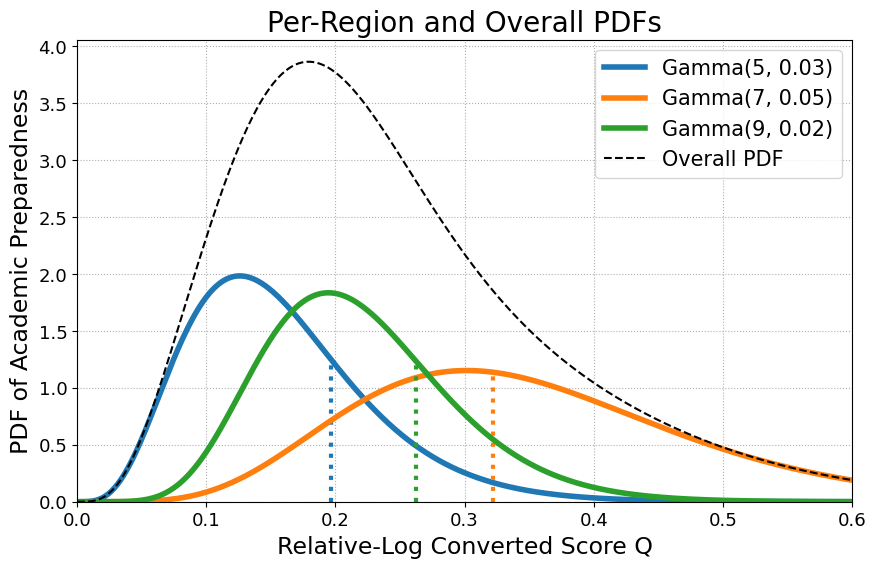

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

n_application_total = np.sum(n_application_a)
n_admission_total = np.sum(n_admission_a)

admit_apply_ratio = n_admission_total / n_application_total

x_values = np.linspace(0, 0.6, 500)
overall_pdf = np.zeros_like(x_values)
overall_cdf = np.zeros_like(x_values)

plt.figure(figsize=(10, 6))

for weight, k, theta, q in zip(z_application_r, k_r, theta_r, q_cutoff_r):
    pdf_values = gamma.pdf(x_values, a=k, scale=theta)
    cdf_values = gamma.cdf(x_values, a=k, scale=theta)
    overall_pdf += weight * pdf_values
    overall_cdf += weight * cdf_values
    line = plt.plot(
        x_values,
        weight * pdf_values,
        label=f"Gamma({k}, {theta:.2f})",
        linewidth=4,
        alpha=1,
    )
    line_color = line[0].get_color()
    ymax = weight * gamma.pdf(x=q, a=k, scale=theta)
    plt.vlines(
        q,
        ymin=0,
        ymax=ymax,
        linestyle=":",
        color=line_color,
        linewidth=3,
    )

plt.plot(
    x_values,
    overall_pdf,
    label="Overall PDF",
    linestyle="--",
    color="black",
)

plt.xlim(0, 0.6)
plt.ylim(bottom=0)
plt.tick_params(axis="both", which="major", labelsize=13)

plt.title("Per-Region and Overall PDFs", fontsize=20)
plt.xlabel("Relative-Log Converted Score Q", fontsize=17)
plt.ylabel("PDF of Academic Preparedness", fontsize=17)
plt.legend(fontsize=15)
plt.grid(True, linestyle=":")

plt.show()